# 01 · The Three Ingredients

Mathematical optimization has **three ingredients and no more**:

1. **Decision variables** — the choices you control.
2. **An objective** — the single quantity to make as large (or small) as possible.
3. **Constraints** — the rules the choices must obey.

Write a business problem in those three terms and a solver does the rest. This
first notebook builds the intuition with **no solver at all** — just geometry on a
two-variable problem you can draw. The claim we will *see* (not assert) is the one
the whole field rests on: **the optimum of a linear program always sits at a corner
of the feasible region.**

We use the classic *Wyndor Glass* product mix: make **doors** and **windows**, each
earning a profit and consuming time at three plants, and choose how many of each to
make to maximise profit.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image

from src.datasets.scenarios import product_mix_scenario
from src.exporters import save_fig, save_json
from src.models import product_mix
from src.visualisation import plot_feasible_region

scenario = product_mix_scenario()
lp = product_mix.build(scenario)
scenario

ProductMixScenario(name='wyndor_glass', products=('doors', 'windows'), profit={'doors': 3.0, 'windows': 5.0}, resources=('plant1', 'plant2', 'plant3'), usage={'plant1': {'doors': 1.0}, 'plant2': {'windows': 2.0}, 'plant3': {'doors': 3.0, 'windows': 2.0}}, capacity={'plant1': 4.0, 'plant2': 12.0, 'plant3': 18.0}, optimum=36.0, optimal_mix={'doors': 2.0, 'windows': 6.0}, shadow_prices={'plant1': 0.0, 'plant2': 1.5, 'plant3': 1.0})

## The ingredients, named

- **Decision variables:** how many *doors* (`d`) and *windows* (`w`) to make.
- **Objective:** maximise profit `3·d + 5·w` (profit per door is 3, per window 5).
- **Constraints:** three plants with limited hours —
  `d ≤ 4` (plant 1), `2·w ≤ 12` (plant 2), `3·d + 2·w ≤ 18` (plant 3), and `d, w ≥ 0`.

Let us write those inputs to JSON so the article and the repo quote the same numbers.

In [2]:
inputs = {
    "problem": "Wyndor Glass product mix (Hillier & Lieberman)",
    "decision_variables": {
        "d": "number of doors to make",
        "w": "number of windows to make",
    },
    "objective": {"direction": "maximize", "coefficients": scenario.profit},
    "constraints": [
        {"name": r, "usage": scenario.usage[r], "limit": scenario.capacity[r], "sense": "<="}
        for r in scenario.resources
    ],
    "nonnegativity": "d, w >= 0",
}
save_json(inputs, "01_three_ingredients_inputs")

PosixPath('/workspaces/optimization_101/outputs/data/01_three_ingredients_inputs.json')

## The feasible region is a polygon

Every constraint cuts the plane with a line; the choices that satisfy *all* of them
form a **feasible region** — here a five-sided polygon. Any point inside is a legal
production plan. The question is which legal plan earns the most.

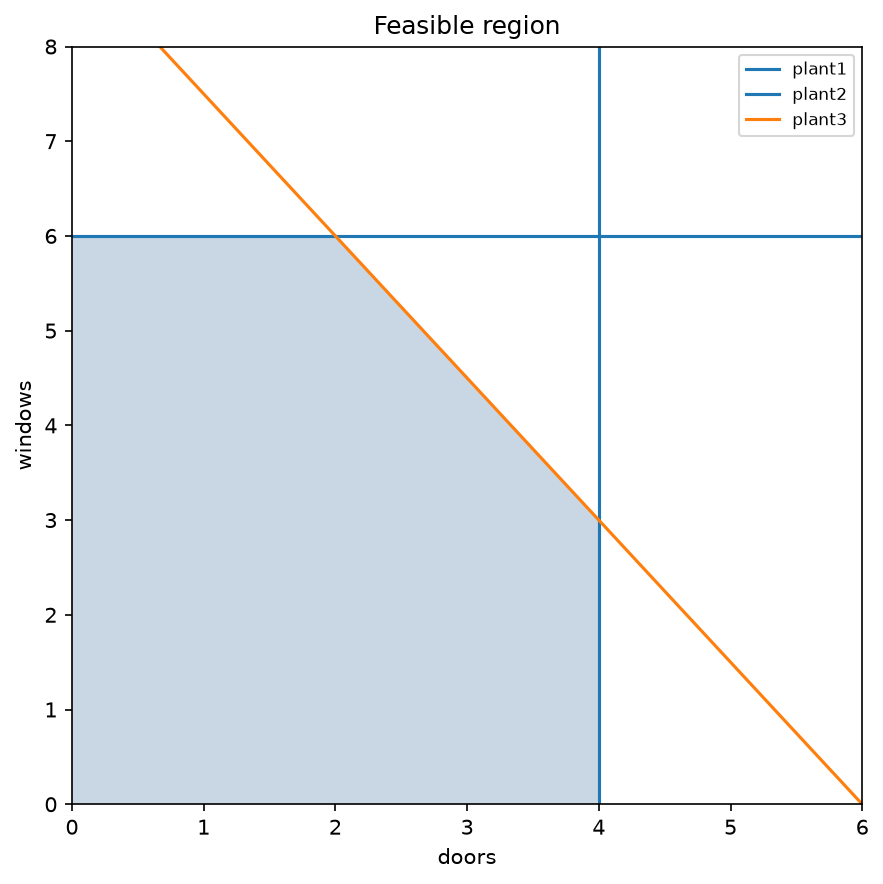

In [3]:
fig = plot_feasible_region(lp, x_max=6, y_max=8)
path = save_fig(fig, "01_feasible_region")
plt.close(fig)
Image(str(path))

## The optimum is at a corner — enumerate and see

A corner (vertex) of the region is where two boundary lines cross *and* every
constraint still holds. There are only a handful. If we evaluate profit at each
corner, the best corner is the global optimum — no search over the interior needed,
because a linear objective is pushed as far as it will go against a flat-sided
region, and that always lands on a corner. We find the corners with pure geometry:
intersect every pair of boundary lines, keep the feasible intersections.

In [4]:
import itertools

# Boundary lines as (a, b, c) meaning a*d + b*w = c (including the axes d=0, w=0).
lines = [
    (1.0, 0.0, 4.0),    # plant 1: d = 4
    (0.0, 2.0, 12.0),   # plant 2: 2w = 12
    (3.0, 2.0, 18.0),   # plant 3: 3d + 2w = 18
    (1.0, 0.0, 0.0),    # d = 0
    (0.0, 1.0, 0.0),    # w = 0
]

def feasible(d, w, tol=1e-9):
    return (
        d >= -tol and w >= -tol
        and d <= 4 + tol and 2 * w <= 12 + tol and 3 * d + 2 * w <= 18 + tol
    )

corners = []
for (a1, b1, c1), (a2, b2, c2) in itertools.combinations(lines, 2):
    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-9:
        continue  # parallel lines, no unique crossing
    d = (c1 * b2 - c2 * b1) / det
    w = (a1 * c2 - a2 * c1) / det
    if feasible(d, w):
        profit = 3 * d + 5 * w
        corner = (round(d, 6), round(w, 6), round(profit, 6))
        if corner not in corners:
            corners.append(corner)

corners.sort(key=lambda t: t[2])
best = max(corners, key=lambda t: t[2])
print("feasible corners (d, w, profit):")
for d, w, profit in corners:
    marker = "  <-- OPTIMUM" if (d, w, profit) == best else ""
    print(f"  ({d:>4}, {w:>4})  profit = {profit:>5}{marker}")
print(f"\noptimum: make {best[0]} doors and {best[1]} windows for profit {best[2]}")

feasible corners (d, w, profit):
  ( 0.0,  0.0)  profit =   0.0
  ( 4.0,  0.0)  profit =  12.0
  ( 4.0,  3.0)  profit =  27.0
  (-0.0,  6.0)  profit =  30.0
  ( 2.0,  6.0)  profit =  36.0  <-- OPTIMUM

optimum: make 2.0 doors and 6.0 windows for profit 36.0


In [5]:
save_json(
    {
        "method": "geometric corner enumeration (no solver)",
        "corners": [{"d": d, "w": w, "profit": p} for d, w, p in corners],
        "optimum": {"d": best[0], "w": best[1], "profit": best[2]},
    },
    "01_three_ingredients_results",
)

PosixPath('/workspaces/optimization_101/outputs/data/01_three_ingredients_results.json')

## Why a corner? Slide the objective line

Lines of constant profit `3·d + 5·w = Z` are parallel. Maximising profit means
pushing that line as far up-and-right as it can go while still touching the feasible
region. The **last point it touches is a corner** — here, 2 doors and 6 windows for
a profit of 36.

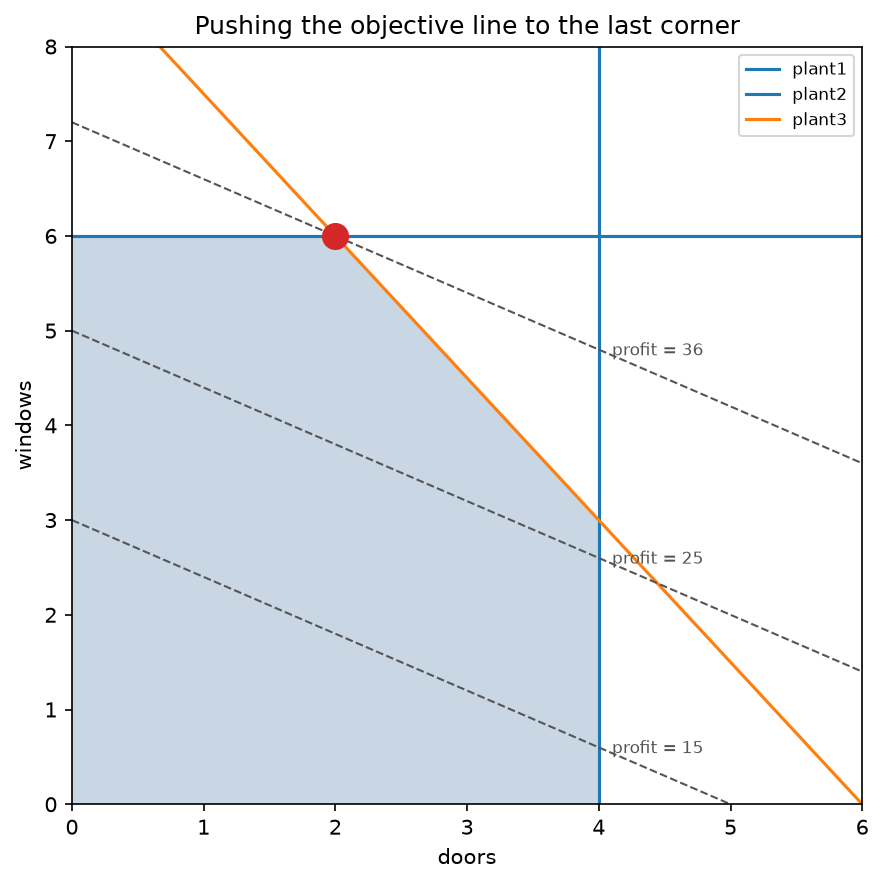

In [6]:
import numpy as np

fig = plot_feasible_region(lp, x_max=6, y_max=8)
ax = fig.axes[0]
dd = np.linspace(0, 6, 50)
for z in [15, 25, 36]:
    ax.plot(dd, (z - 3 * dd) / 5, "--", color="#555", linewidth=1)
    ax.annotate(f"profit = {z}", (4.1, (z - 3 * 4.1) / 5), fontsize=8, color="#555")
ax.plot(best[0], best[1], "o", color="#d62728", markersize=12, zorder=6)
ax.set_title("Pushing the objective line to the last corner")
path = save_fig(fig, "01_objective_slide")
plt.close(fig)
Image(str(path))

## The mental model for the whole project

- A linear program is **three lists**: variables, an objective, constraints.
- Its feasible region is a polygon (a polytope in higher dimensions).
- Its optimum is **always at a corner**, so a solver never has to search the interior
  — it walks intelligently from corner to corner (that is the simplex method, which we
  build from scratch in notebook 06).

No solver appeared in this notebook. In **notebook 02** we write the same problem down
and hand it to a free solver, which returns this exact answer in milliseconds — and
then optimization stops being theory.